In [107]:
import random
import numpy as np
import json
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from mg_dataset.dataset import MGDataset
from mg_dataset.preprocesing import filters
from mg_dataset.preprocesing import cycles

import mg_tools.stats as stats
import mg_tools.recording_analysis as analysis

from mg_tools.recording_visualisers import RecordingVisualiser as vis

DEFAULT_DATABASE = '../Database/mg-data'
VALIDATION_PATH = '../exports/cv_config.json'

# DATASET INITIALISATION

In [2]:
DATASET = MGDataset(DEFAULT_DATABASE)

# HELPERS

## cycle structure

In [43]:
# saccade and state finding strats

def find_saccades(
    cycle_vel:list[float], 
    depart_threshold:float=30.0,
    return_threshold:float=10.0,
    samples_between_saccades:int=5,
    debug = -1
) -> list[list[int,int]]:
    abs_vel = [abs(v) for v in cycle_vel]

    in_saccade = False
    saccade_cooldown = 0
    saccade_storage = []

    for vel_idx, vel in enumerate(abs_vel):
        if debug > 2:
            print(f'({vel_idx:03d}): {vel:07.4f} | IN SACCADE? {in_saccade}')

        # wait to find next_saccade
        if saccade_cooldown:
            if debug > 3:
                print(f'   ({vel_idx:03d}): {vel:07.4f} | IN COOLDOWN {saccade_cooldown}')
            saccade_cooldown -= 1
            continue

        if in_saccade:
            if vel > return_threshold:
                continue

            for next_idx in range(vel_idx+1, min(vel_idx+samples_between_saccades+1, len(abs_vel))):
                next_val=abs_vel[next_idx]
                
                if debug > 3:
                    print(f'     ({vel_idx:03d}): (next_idx){next_idx} (next_val){next_val:07.4f} | CHECKING NEARBY SACCADE ')

                if next_val > depart_threshold:
                    saccade_cooldown = next_idx-vel_idx
                    break

            if saccade_cooldown != 0:
                if debug > 2:
                    print(f'    ({vel_idx:03d}): NEARBY SACCADE ')
                continue

            in_saccade = False
            saccade_storage[-1].append(vel_idx)
            saccade_cooldown = samples_between_saccades

            if debug > 1:
                print(f'   ({vel_idx:03d}): (vel){vel:07.4f} < (ret_thresh){return_threshold} | NOT IN SACCADE ')

        else:
            if vel < depart_threshold:
                continue

            in_saccade = True

            if debug > 0:
                print(f'  ({vel_idx:03d}): (vel){vel:07.4f} > (dep_thresh){depart_threshold} | IN SACCADE ')

            for prev_idx in range(vel_idx, 0, -1):
                
                if (prev_val:=abs_vel[prev_idx]) < return_threshold:
                    if debug > 3:
                        print(f'    ({vel_idx:03d}): (prev_idx){prev_idx} IS (prev_val){prev_val:07.4f} < (ret_thresh){return_threshold}')
                    break

                if debug > 4:
                    print(f'    ({vel_idx:03d}): (prev_idx){prev_idx} IS (prev_val){prev_val:07.4f}')

            saccade_info = [prev_idx, ]
            saccade_storage.append(saccade_info)

    if in_saccade and len(saccade_storage[-1])==1:
        saccade_storage[-1].append(len(abs_vel)-1)

    return saccade_storage

def find_states(
    cycle_pos:list[float],
    saccade_indices:list[list[int,int]],
    state_depart_thresh:float=10.0,
    state_stable_thresh:float=2.0,
    state_transition_thresh:float=25.0,
    debug = -1
) -> list[list[int,int]]:
    n = len(cycle_pos)
    last_direction = None
    state_storage = [[0]]

    for saccade_start, saccade_end in saccade_indices:
        last_pair = state_storage[-1]
        last_state = last_pair[-1]
        last_state_pos = cycle_pos[last_state]

        sac_start_pos = cycle_pos[saccade_start]
        sac_end_pos = cycle_pos[saccade_end]

        if debug > 1:
            print(f'LAST PAIR: {last_pair} | LAST STATE POS {last_state_pos} | SACCADE PAIR {(saccade_start, saccade_end)} {(sac_start_pos, sac_end_pos)}')

        # saccade does not depart state
        # and does not enter new state since last position
        if (sac_dep:=abs(sac_end_pos - last_state_pos)) < state_depart_thresh:
            if debug > 2:
                print(f' SACCADE DEPARTURE {sac_dep} < state_depart_thresh {state_depart_thresh}\n')
            continue

        # state is unfinished
        if len(last_pair) == 1:
            state_start_pos = last_state_pos
            
            saccade_range = abs(sac_end_pos-sac_start_pos)

            saccade_goes_up = sac_end_pos > sac_start_pos

            # saccade doesnt departs current state
            if (state_stable:=abs(sac_start_pos-state_start_pos)) < state_stable_thresh:
                state_storage[-1].append(saccade_start)

            # saccade enters new state
            if saccade_range > state_transition_thresh:
                state_storage.append([saccade_end])

            if debug > 0:
                msg  = f' ONE LAST STATE - CASE A \n'
                msg += f'  LAST STATE POS {state_start_pos} | SACCADE PAIR {(saccade_start, saccade_end)} {(sac_start_pos, sac_end_pos)} |\n'
                msg += f'  STATE STABLE {state_stable} < (state_stable_thresh) {state_stable_thresh} ? |\n'
                msg += f'  SACCADE RANGE {saccade_range} > (state_transition_thresh) {state_transition_thresh} ? |\n'
                msg += f'  STATE STORAGE {state_storage}\n'
                print(msg)

        # state is finished, look for new state
        else:
            state_storage.append([saccade_end])
            if debug > 0:
                msg  = f' TWO LAST STATE - CASE B \n'
                msg += f'  LAST STATE POS {state_start_pos} | SACCADE PAIR {(saccade_start, saccade_end)} {(sac_start_pos, sac_end_pos)} |\n'
                msg += f'  STATE STORAGE {state_storage}\n'
                print(msg)

    # close final state with end of cycle
    if len(state_storage[-1]) == 1:
        state_storage[-1].append(n-1)
    else:
        state_storage.append([saccade_end, n-1])

    return state_storage

def get_cycle_state_and_saccade(
    cycle_pos:dict, 
    cycle_vel:dict,
    channel_names = ('L','R'),
    depart_threshold:float=30.0,
    return_threshold:float=10.0,
    samples_between_saccades:int=5,
    state_depart_thresh:float=10.0,
    state_stable_thresh:float=2.0,
    state_transition_thresh:float=25.0
) -> dict[str,dict[str,list]]:
    output_dict = {k:{} for k in channel_names}

    for channel in output_dict:
        output_dict[channel]['saccades'] = (channel_saccades := find_saccades(
            cycle_vel[channel], depart_threshold, return_threshold, samples_between_saccades
        ))
        output_dict[channel]['states'] = find_states(
            cycle_pos[channel], channel_saccades, state_depart_thresh, state_stable_thresh, state_transition_thresh
        )

    return output_dict

## rendering

### custom renderers

In [127]:
def draw_separate_channels(
    cycle_pos:dict, 
    cycle_vel:dict, 
    channel_names = ('L','R'), 
    highlights:dict = None,
    title = 'separated channels',
    pos_y_boundaries = (-25, 25),
    pos_y_steps = 5,
    vel_y_boundaries = (-500, 500),
    vel_y_steps = 50,
    canvas_constructor = None,
    **canvas_kwargs
) -> tuple[plt.Figure, plt.Axes]:

    default_fig_args = {
        'nrows':2,
        'ncols':2,
        'figsize':(24,14),
        'dpi' : 100,
    }
    
    canvas_kwargs = {} if canvas_kwargs is None else canvas_kwargs
    fig_args = default_fig_args | canvas_kwargs

    if canvas_constructor is None:
        canvas_constructor = vis._canvas_constructor_factory(True)

    fig, axs = canvas_constructor(**fig_args)

    fig.suptitle(title)

    for attr_idx, attr in enumerate((cycle_pos, cycle_vel)):
        ax_row = axs[attr_idx]

        attr_name = ['pos','vel'][attr_idx]
        y_bounds = (pos_y_boundaries, vel_y_boundaries)[attr_idx]
        y_steps = (pos_y_steps, vel_y_steps)[attr_idx]

        for channel_idx, channel_name in enumerate(channel_names):
            ax : plt.Axes = ax_row[channel_idx]

            ax.set_ybound(*y_bounds)

            channel_data = attr[channel_name]
            target_list = cycle_pos['target_list']
            ax2 = ax.twinx()

            ax.plot(channel_data, label = f'{attr_name} {channel_name}')
            ax2.plot(target_list, ':', color='red', label = 'target')

            if highlights is not None:
               try:
                for highlight_idx, (state_start, state_end) in enumerate(highlights[channel_name]['states']):
                    ax.fill_betweenx(
                        list(range(*map(int, ax.get_ybound()))), 
                        state_start, state_end,
                        alpha=0.4,
                        color=(0.85,0.33,0.33)
                    )
               except ValueError:
                    print(
                        'Unpacking error', 
                        f' channel: {channel_name} | idx: {highlight_idx}', 
                        f' {highlights[channel_name]['states'][highlight_idx]}',
                        sep = '\n'
                    )
                    pass

            ax.legend(loc='lower left')
            ax2.legend(loc='upper right')
            
            ax.set_title(f'{attr_name} {channel_name}')

            ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
            ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))

            y_bounds = ax.get_ybound()
            while (y_bounds[1]-y_bounds[0])/y_steps > 30:
                y_steps *= 2

            ax.yaxis.set_major_locator(ticker.MultipleLocator(y_steps))
            ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_steps/5))

            ax.tick_params(axis='x', labelsize=5, rotation=45)

            ax.grid(True)
            ax.grid(True, 'minor', alpha=0.3)

    return fig,axs

### comparisons

In [3]:
def compare_figures(figures_dict:dict[str,dict], y_major_locator=2.5, y_minor_locator=1):
    fig, axs = plt.subplots(1, 3, figsize=(30,10), dpi=100, constrained_layout=True)
    for ax_idx, (ax_name, ax_data) in enumerate(figures_dict.items()):
        ax: plt.Axes = axs[ax_idx]
        ax.set_title(ax_name)

        for k in ('L','R'):
            ax.plot(ax_data[k], label=k)

        ax.xaxis.set_major_locator(ticker.MultipleLocator(60))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(15))

        ax.yaxis.set_major_locator(ticker.MultipleLocator(y_major_locator))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(y_minor_locator))

        ax.grid(True)
        ax.grid(True, 'minor', alpha=0.3)
        ax.legend()

    plt.show()

# SINGLE CYCLE TESTS

In [122]:
get_vel = lambda pos_dict, filter_size : {
    k:stats.median_rolling_average(stats.rate_of_change(pos_dict[k]), filter_size) for k in ('L','R')
}

sample_idx = 135
cycle_idx = 74

kernel_size = 7

sample = DATASET.load_csv(sample_idx)
sample_cycles = cycles.get_cycles(sample['Target'])

sample_meta = sample['meta']
sample_name = ' | '.join([sample_meta[k] for k in ('group', 'date', 'axis', 'frequency')])
sample_name = f'sample #{sample_idx} | {sample_name} | cycle #{cycle_idx} | kernel size: {kernel_size}'

start, end = sample_cycles[cycle_idx]

raw_cycle = {
    'L':sample['L'][start:end], 
    'R':sample['R'][start:end],
    'time_list': sample['time'][start:end],
    'target_list': sample['Target'][start:end]
}

median_filtered_cycle = raw_cycle | {
    'L':filters.denoise(sample['L'][start:end]),
    'R':filters.denoise(sample['R'][start:end])
}

# median_filtered_cycle = raw_cycle | {
#     'L': stats.rolling_average(sample['L'][start:end], kernel_size=kernel_size, method='median'),
#     'R': stats.rolling_average(sample['R'][start:end], kernel_size=kernel_size, method='median')
# }

vel_median_filtered_cycle = raw_cycle | get_vel(median_filtered_cycle, 0)

Unpacking error
 channel: L | idx: 0
 [0]
Unpacking error
 channel: L | idx: 0
 [0]


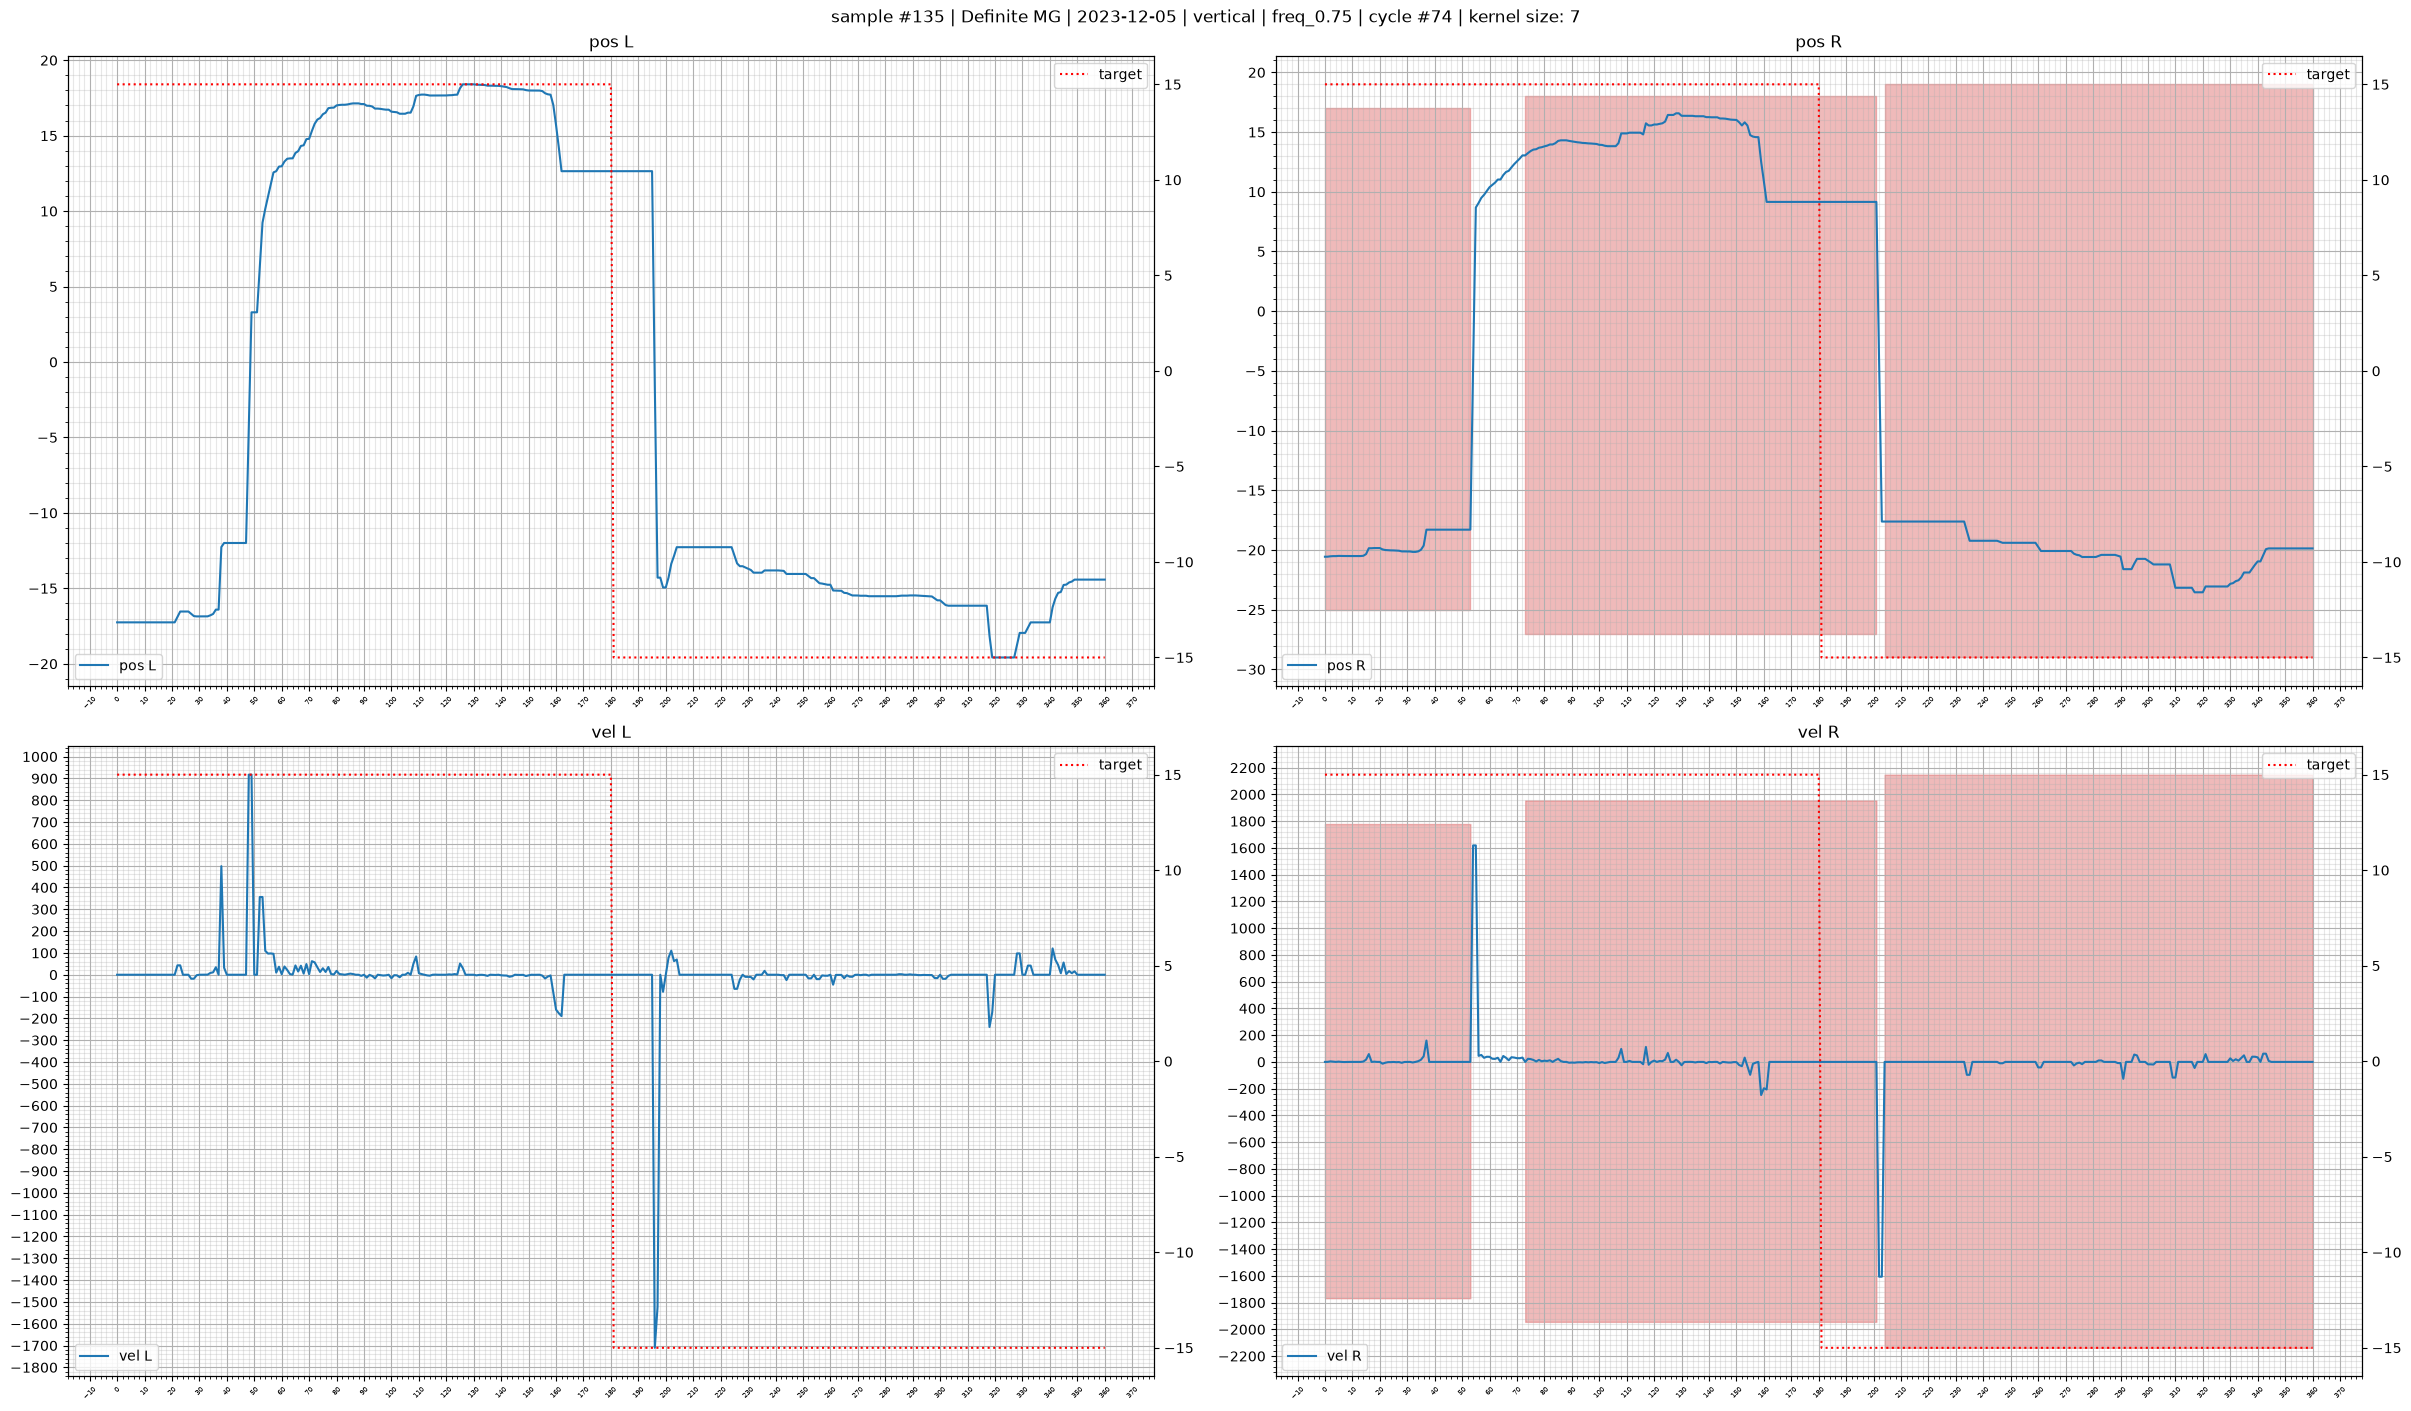

In [128]:
vis.show_graph(
    draw_separate_channels,
    cycle_pos = median_filtered_cycle,
    cycle_vel = vel_median_filtered_cycle,
    highlights = get_cycle_state_and_saccade(
        median_filtered_cycle, vel_median_filtered_cycle,
        depart_threshold=30,
        state_depart_thresh=6.45,
        state_transition_thresh=19,
        state_stable_thresh=5.0
    ),
    vel_y_boundaries = (None,None),
    title = sample_name
)

In [41]:
test_side = 'R'

test_sac = find_saccades(
    vel_median_filtered_cycle[test_side],
    debug = 5
)
test_sac

(000): 00.0000 | IN SACCADE? False
(001): 01.4068 | IN SACCADE? False
(002): 00.7338 | IN SACCADE? False
(003): 00.7338 | IN SACCADE? False
(004): 01.7678 | IN SACCADE? False
(005): 00.0000 | IN SACCADE? False
(006): 01.6626 | IN SACCADE? False
(007): 01.1581 | IN SACCADE? False
(008): 00.0000 | IN SACCADE? False
(009): 00.0000 | IN SACCADE? False
(010): 00.8432 | IN SACCADE? False
(011): 00.9760 | IN SACCADE? False
(012): 00.9760 | IN SACCADE? False
(013): 00.0000 | IN SACCADE? False
(014): 06.8729 | IN SACCADE? False
(015): 00.0000 | IN SACCADE? False
(016): 00.6702 | IN SACCADE? False
(017): 78.6245 | IN SACCADE? False
  (017): (vel)78.6245 > (dep_thresh)30.0 | IN SACCADE 
    (017): (prev_idx)17 IS (prev_val)78.6245
    (017): (prev_idx)16 IS (prev_val)00.6702 < (ret_thresh)10.0
(018): 372.0859 | IN SACCADE? True
(019): 488.8376 | IN SACCADE? True
(020): 519.4820 | IN SACCADE? True
(021): 479.9424 | IN SACCADE? True
(022): 431.2006 | IN SACCADE? True
(023): 354.5479 | IN SACCADE? T

[[16, 27], [45, 49], [74, 77], [131, 136], [174, 180], [188, 201], [216, 220]]

In [42]:
find_states(
    median_filtered_cycle[test_side], test_sac,
    state_depart_thresh=6.5,
    state_transition_thresh=17,
    state_stable_thresh=4.5,
    debug=3
)

LAST PAIR: [0] | LAST STATE POS -15.164257 | SACCADE PAIR (16, 27) (-15.13726, 14.445366)
 ONE LAST STATE - CASE A 
  LAST STATE POS -15.164257 | SACCADE PAIR (16, 27) (-15.13726, 14.445366) |
  STATE STABLE 0.026996999999999716 < (state_stable_thresh) 4.5 ? |
  SACCADE RANGE 29.582625999999998 > (state_transition_thresh) 17 ? |
  STATE STORAGE [[0, 16], [27]]

LAST PAIR: [27] | LAST STATE POS 14.445366 | SACCADE PAIR (45, 49) (14.463623, 16.640724)
 SACCADE DEPARTURE 2.195357999999999 < state_depart_thresh 6.5

LAST PAIR: [27] | LAST STATE POS 14.445366 | SACCADE PAIR (74, 77) (16.955582, 16.587982)
 SACCADE DEPARTURE 2.1426160000000003 < state_depart_thresh 6.5

LAST PAIR: [27] | LAST STATE POS 14.445366 | SACCADE PAIR (131, 136) (16.558746, 17.284729)
 SACCADE DEPARTURE 2.8393629999999987 < state_depart_thresh 6.5

LAST PAIR: [27] | LAST STATE POS 14.445366 | SACCADE PAIR (174, 180) (17.30793, 19.759178)
 SACCADE DEPARTURE 5.313811999999999 < state_depart_thresh 6.5

LAST PAIR: [27]

[[0, 16], [27, 361]]

## batch tests

In [37]:
# random sampling and imaging
random_samples = random.sample(list(range(len(DATASET.files))),100)

In [ ]:
for sample_iter, sample_idx in enumerate(random_samples):
    kernel_size = 7

    sample = DATASET.load_csv(sample_idx)
    sample_cycles = cycles.get_cycles(sample['Target'])
    cycle_idx = random.randint(0,len(sample_cycles)-1)

    sample_meta = sample['meta']
    sample_name = ' | '.join([sample_meta[k] for k in ('group', 'date', 'axis', 'frequency')])
    sample_name = f'sample #{sample_idx} | {sample_name} | cycle #{cycle_idx} | kernel size: {kernel_size}'

    start, end = sample_cycles[cycle_idx]

    get_vel = lambda pos_dict, filter_size : {
        k:stats.median_rolling_average(stats.rate_of_change(pos_dict[k]), filter_size) for k in ('L','R')
    }

    raw_cycle = {
        'L':sample['L'][start:end], 
        'R':sample['R'][start:end],
        'time_list': sample['time'][start:end],
        'target_list': sample['Target'][start:end]
    }

    vel_raw_cycle = get_vel(raw_cycle, 0)

    median_filtered_cycle = raw_cycle | {
        'L':filters.denoise(sample['L'][start:end]),
        'R':filters.denoise(sample['R'][start:end])
    }

    # median_filtered_cycle = raw_cycle | {
    #     'L': stats.rolling_average(sample['L'][start:end], kernel_size=kernel_size, method='median'),
    #     'R': stats.rolling_average(sample['R'][start:end], kernel_size=kernel_size, method='median')
    # }

    vel_median_filtered_cycle = get_vel(median_filtered_cycle, 0)

    try:
        # vis.save_graph(
        #     draw_separate_channels,
        #     target_dir='../exports/figures/state_separation/',
        #     my_file_name=f'{sample_iter:03d}-sample_{sample_idx}-cycle_{cycle_idx}-kernel_{kernel_size}-state',
        #     target_extension='jpg',
        #     cycle_pos = median_filtered_cycle,
        #     cycle_vel = vel_median_filtered_cycle,
        #     highlights = get_cycle_state_and_saccade(
        #         median_filtered_cycle, vel_median_filtered_cycle,
        #         depart_threshold=30,
        #         state_depart_thresh=6.5,
        #         state_transition_thresh=17,
        #         state_stable_thresh=5.0
        #     ),
        #     vel_y_boundaries = (None,None),
        #     title = sample_name
        # )
    except Exception as e:
        print(e)
        print(sample_idx, cycle_idx)
        break
    finally:
        print(sample_iter+1, sample_idx, cycle_idx)


In [119]:
with open(VALIDATION_PATH) as validation_json:
    validations = json.load(validation_json)
    
val_samples = []

for vold in validations['folds']:
    for file in vold['train']['healthy'] + vold['train']['mg']:
        val_samples += [file[:-5]]
    break

val_samples = list(set(val_samples))
val_samples_2 = []

for sample_idx, (patient_str) in enumerate(val_samples):
    group, patient_idx = list(map(int, patient_str.split('-')))
    visit_idx = 0

    while True:
        try:
            visit = DATASET.get_files(group, patient_idx, visit_idx)
        except IndexError:
            break

        for file in visit:
            val_samples_2.append(file)

        visit_idx += 1

val_samples = val_samples_2

In [134]:
kernel_size = 7
get_vel = lambda pos_dict, filter_size : {
    k:stats.median_rolling_average(stats.rate_of_change(pos_dict[k]), filter_size) for k in ('L','R')
}

for sample_idx, sample_info in enumerate(val_samples):
    sample = DATASET.load_csv_of(sample_info)
    sample_cycles = cycles.get_cycles(sample['Target'])
    
    for cycle_idx, (start, end) in enumerate(sample_cycles):
        sample_meta = sample['meta']
        meta_order = [sample_meta[k] for k in ('group', 'date', 'frequency','axis')]
        
        sample_path = os.path.join('..','exports','figures','validation',*meta_order)

        sample_name = ' | '.join([f'cycle_idx #{cycle_idx}'] + meta_order)
    
        raw_cycle = {
            'L':sample['L'][start:end], 
            'R':sample['R'][start:end],
            'time_list': sample['time'][start:end],
            'target_list': sample['Target'][start:end]
        }

        vel_raw_cycle = raw_cycle | get_vel(raw_cycle, 0)

        median_filtered_cycle = raw_cycle | {
            'L':filters.denoise(sample['L'][start:end]),
            'R':filters.denoise(sample['R'][start:end])
        }

        vel_median_filtered_cycle = raw_cycle | get_vel(median_filtered_cycle, 0)

        raw_path = os.path.join(sample_path, 'raw')
        filtered_path = os.path.join(sample_path, 'filtered')

        os.makedirs(raw_path, exist_ok=True)
        os.makedirs(filtered_path, exist_ok=True)

        try:
            vis.save_graph(
                draw_separate_channels,
                target_dir=raw_path,
                my_file_name=f'{sample_iter:03d}-sample_{sample_idx}-cycle_{cycle_idx}-raw',
                target_extension='jpg',
                do_overwrite=True,
                cycle_pos = raw_cycle,
                cycle_vel = vel_raw_cycle,
                highlights = None,
                vel_y_boundaries = (None,None),
                title = sample_name + ' | raw'
            )
        except Exception as e:
            print('raw', e)
            print(sample_idx, cycle_idx)
            break
        finally:
            print('raw', sample_idx, cycle_idx)

        try:
            vis.save_graph(
                draw_separate_channels,
                target_dir=filtered_path,
                my_file_name=f'sample_{sample_idx}-cycle_{cycle_idx}-filtered',
                target_extension='jpg',
                do_overwrite=True,
                cycle_pos = median_filtered_cycle,
                cycle_vel = vel_median_filtered_cycle,
                highlights = None,
                vel_y_boundaries = (None,None),
                title = sample_name + ' | filtered'
            )
        except Exception as e:
            print('filtered', e)
            print(sample_idx, cycle_idx)
            break
        finally:
            print('filtered', sample_idx, cycle_idx)


raw 0 0
filtered 0 0
raw 0 1
filtered 0 1
raw 0 2
filtered 0 2
raw 0 3
filtered 0 3
raw 0 4
filtered 0 4
raw 0 5
filtered 0 5
raw 0 6
filtered 0 6
raw 0 7
filtered 0 7
raw 0 8
filtered 0 8
raw 0 9
filtered 0 9
raw 0 10
filtered 0 10
raw 0 11
filtered 0 11
raw 0 12
filtered 0 12
raw 0 13
filtered 0 13
raw 0 14
filtered 0 14
raw 0 15
filtered 0 15
raw 0 16
filtered 0 16
raw 0 17
filtered 0 17
raw 0 18
filtered 0 18
raw 0 19
filtered 0 19
raw 0 20
filtered 0 20
raw 0 21
filtered 0 21
raw 0 22
filtered 0 22
raw 0 23
filtered 0 23
raw 0 24
filtered 0 24
raw 0 25
filtered 0 25
raw 0 26
filtered 0 26
raw 0 27
filtered 0 27
raw 0 28
filtered 0 28
raw 0 29
filtered 0 29
raw 0 30
filtered 0 30
raw 0 31
filtered 0 31
raw 0 32
filtered 0 32
raw 0 33
filtered 0 33
raw 0 34
filtered 0 34
raw 0 35
filtered 0 35
raw 0 36
filtered 0 36
raw 0 37
filtered 0 37
raw 0 38
filtered 0 38
raw 0 39
filtered 0 39
raw 0 40
filtered 0 40
raw 0 41
filtered 0 41
raw 0 42
filtered 0 42
raw 0 43
filtered 0 43
raw 0 44

KeyboardInterrupt: 

## additional processing

In [ ]:
raw_cycle = {
    'L':sample['L'][start:end], 
    'R':sample['R'][start:end],
    'time_list': sample['time'][start:end],
    'target_list': sample['Target'][start:end]
}

mean_filtered_cycle = raw_cycle| {
    'L': stats.rolling_average(sample['L'][start:end], kernel_size=kernel_size),
    'R': stats.rolling_average(sample['R'][start:end], kernel_size=kernel_size)
}


position_dicts = {
    'raw cycle': raw_cycle,
    'mean filtered cycle': mean_filtered_cycle,
    'median filtered cycle': median_filtered_cycle,
}

vel_raw_cycle = get_vel(raw_cycle)
vel_mean_filtered_cycle = get_vel(mean_filtered_cycle)
vel_median_filtered_cycle = get_vel(median_filtered_cycle)

vel_dicts = {
    'vel raw cycle' : vel_raw_cycle,
    'vel mean filtered cycle': vel_mean_filtered_cycle,
    'vel median filtered cycle': vel_median_filtered_cycle
}

## compare filterings

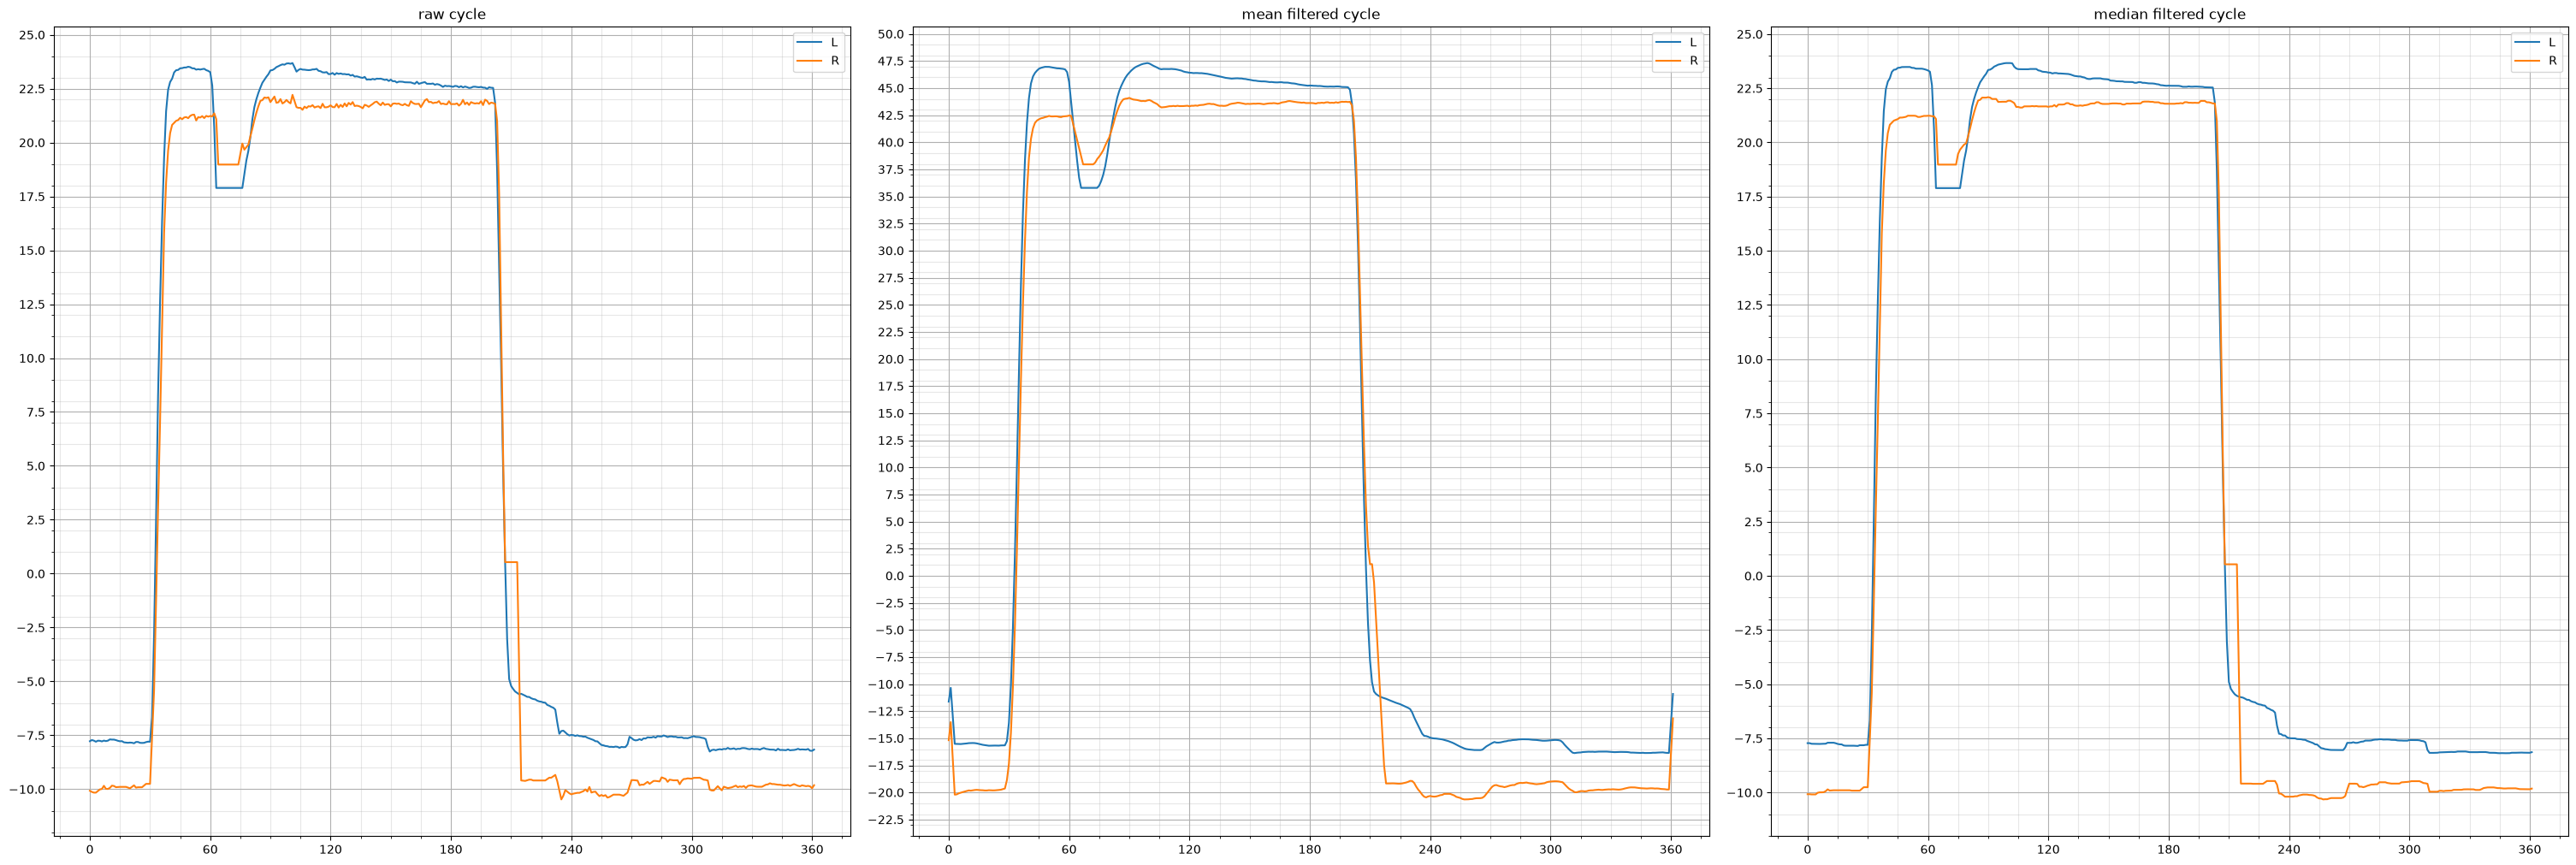

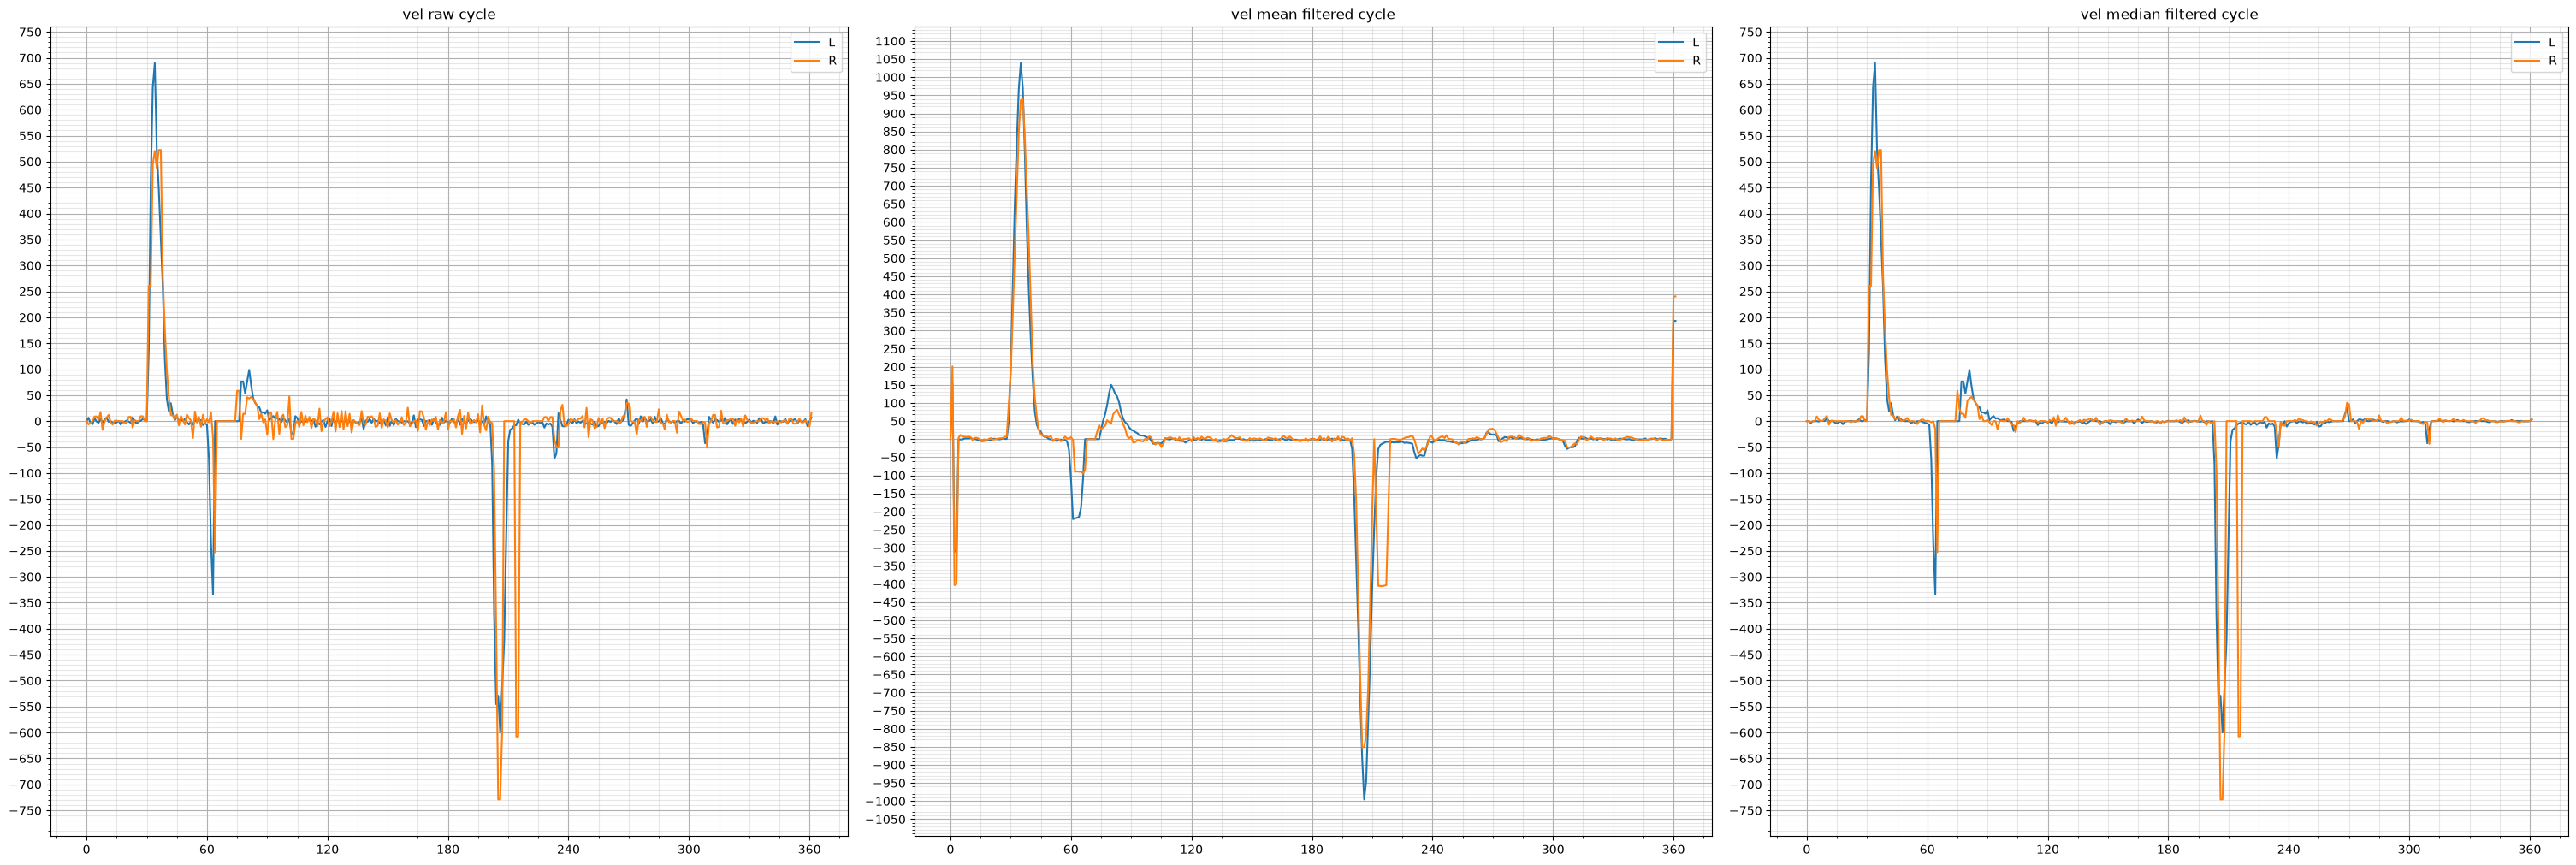

In [5]:
compare_figures(position_dicts)
compare_figures(vel_dicts, 50, 10)

## render cycle

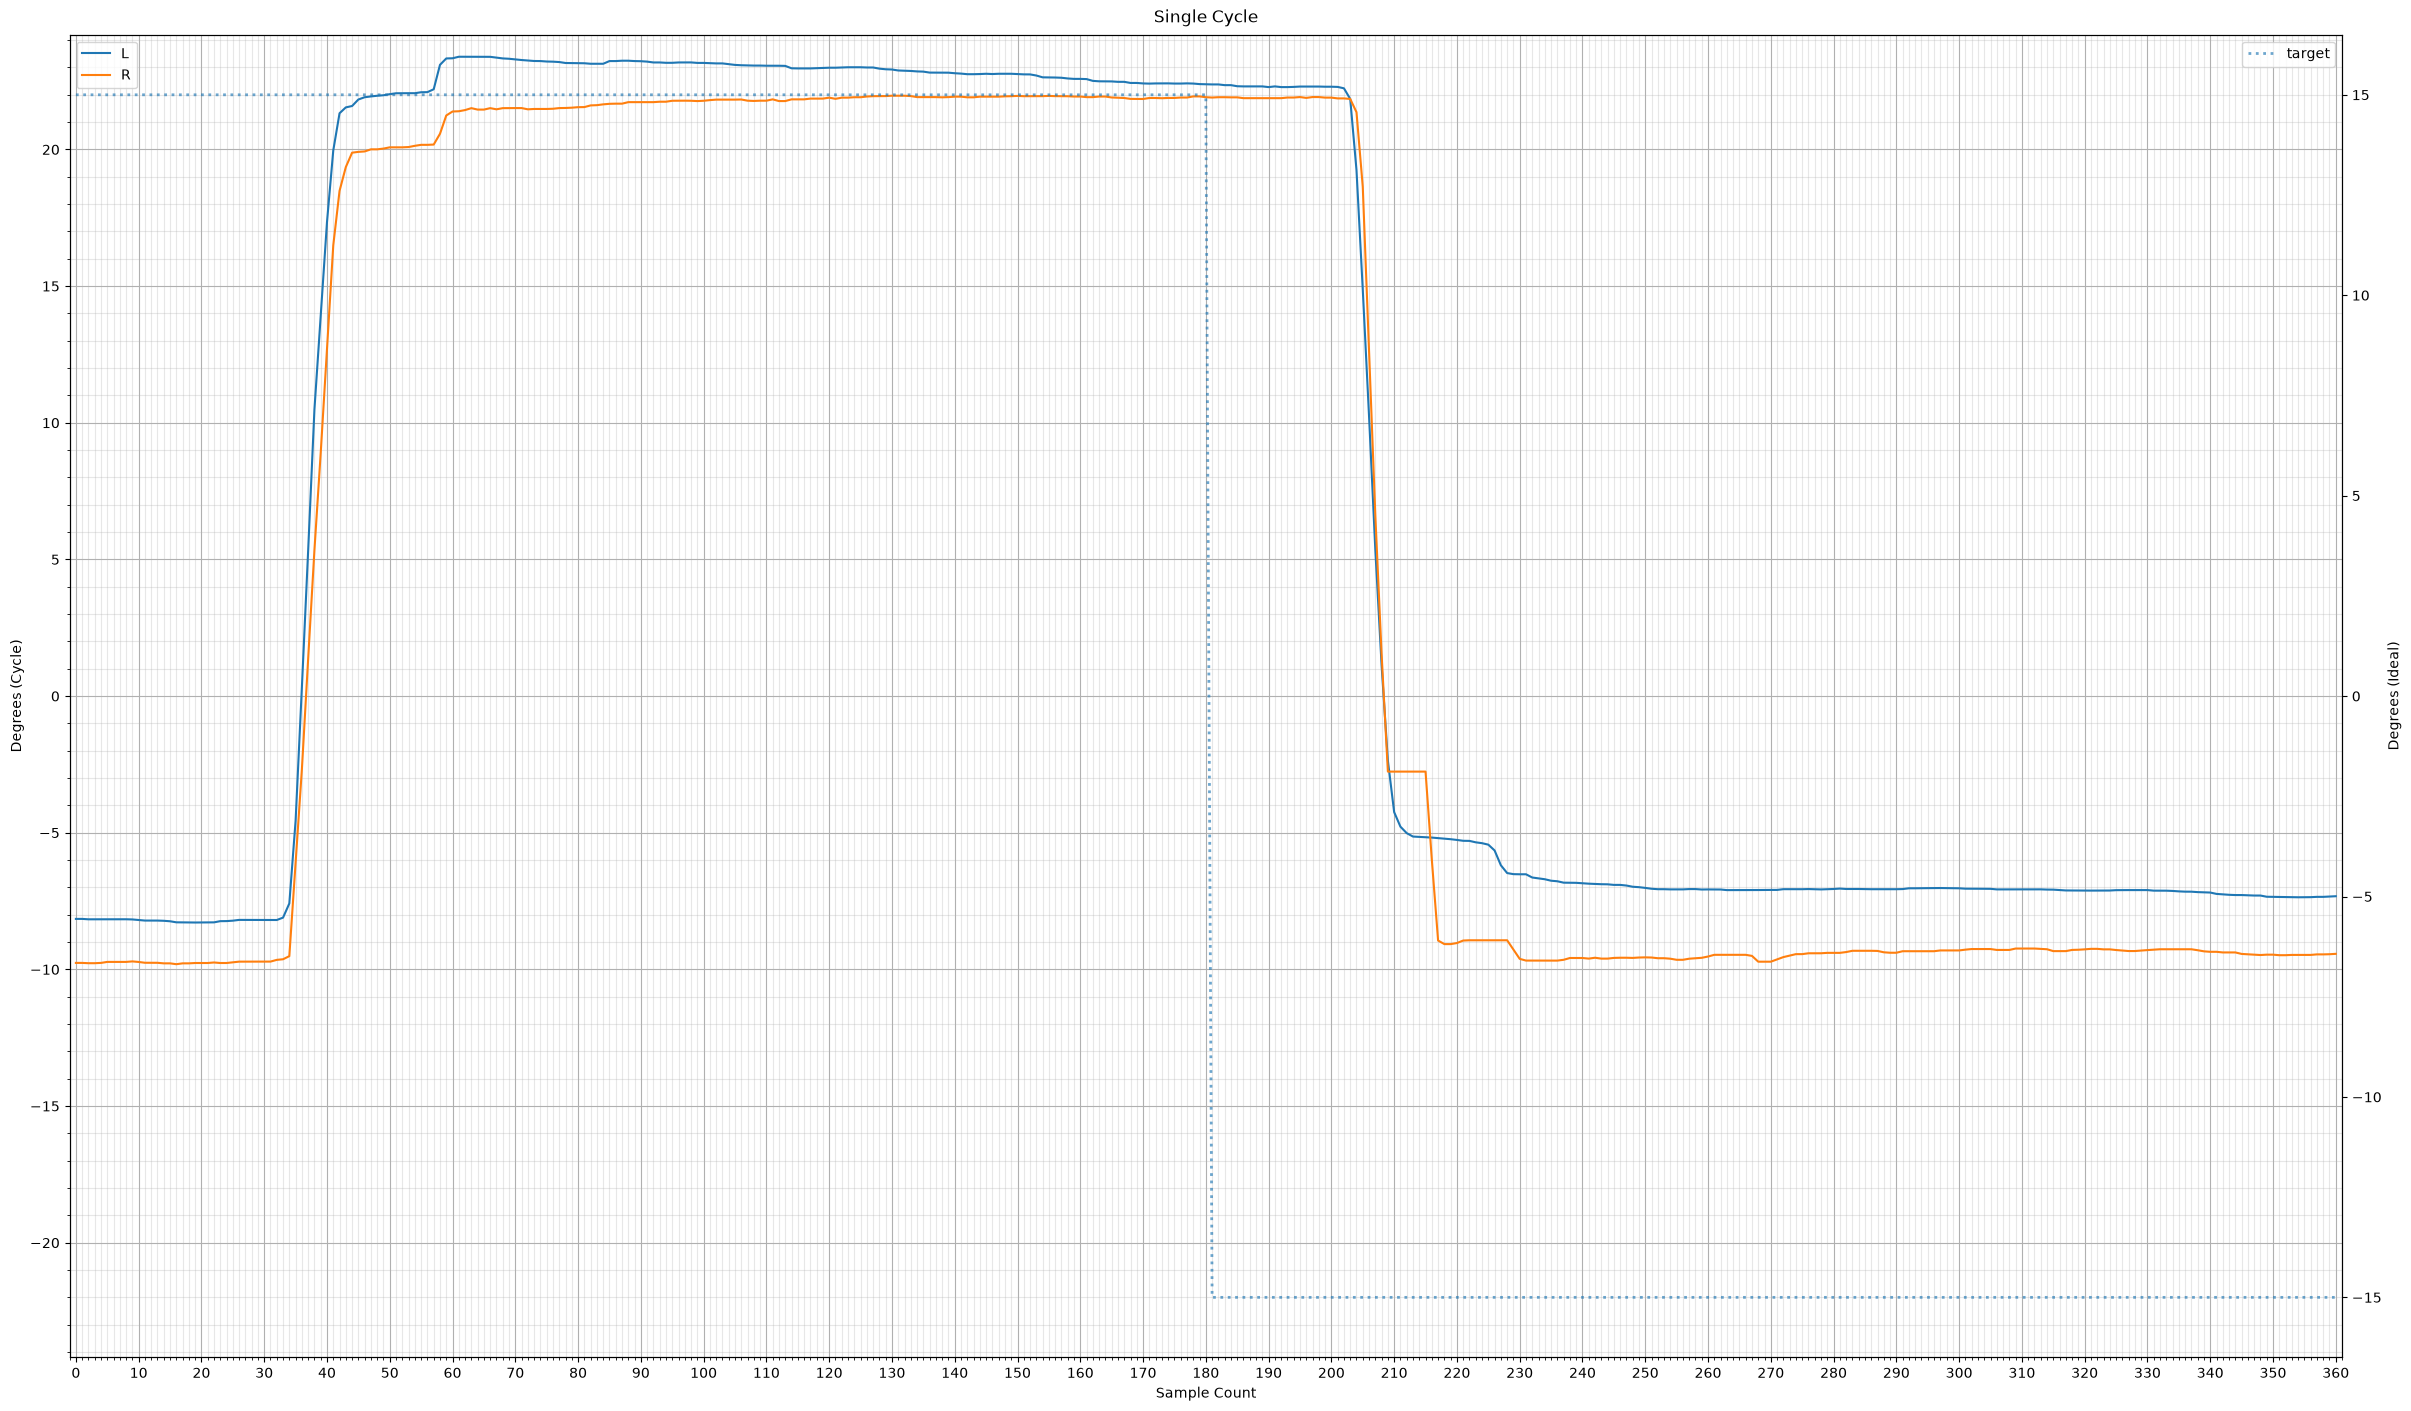

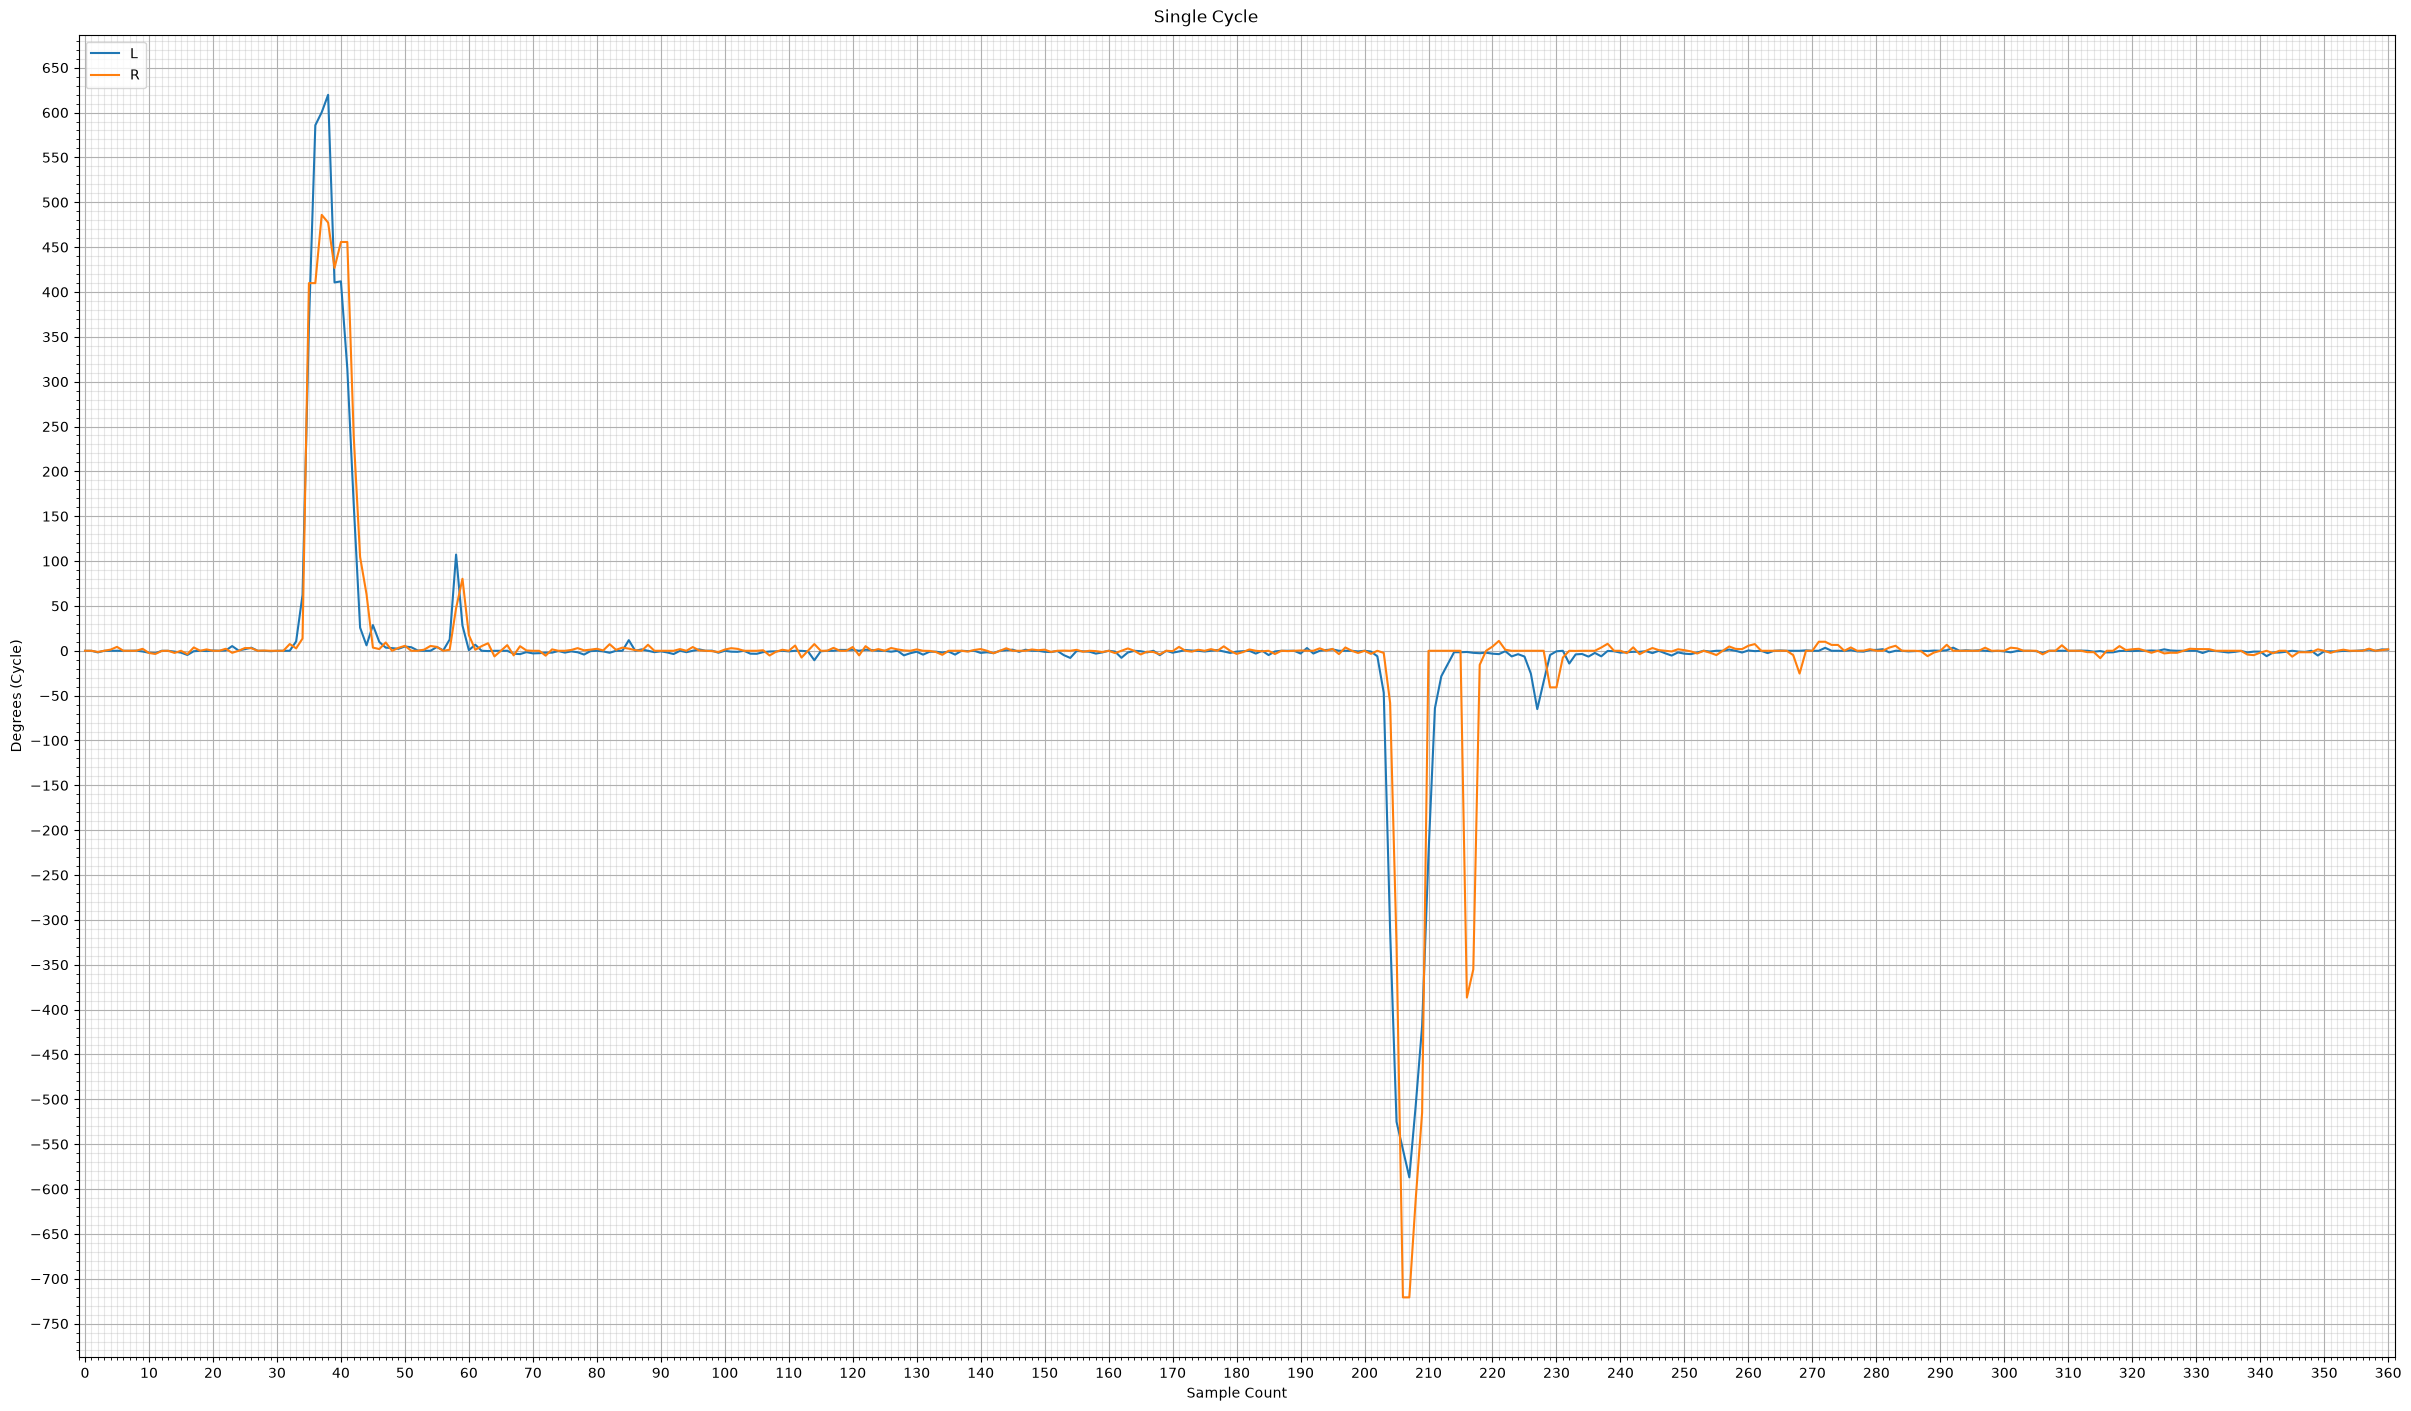

In [ ]:
vis.show_graph(
    vis.draw_single_cycle_of,
    median_filtered_cycle,
    channel_names = ('L','R')
)

vis.show_graph(
    vis.draw_single_cycle_of,
    vel_median_filtered_cycle,
    channel_names = ('L','R'),
    value_y_bounds = (None, None),
    value_y_step = 50
)